DATASET SHAPE
(32581, 12)

DATASET COLUMNS
Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

FIRST 5 ROWS
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL      

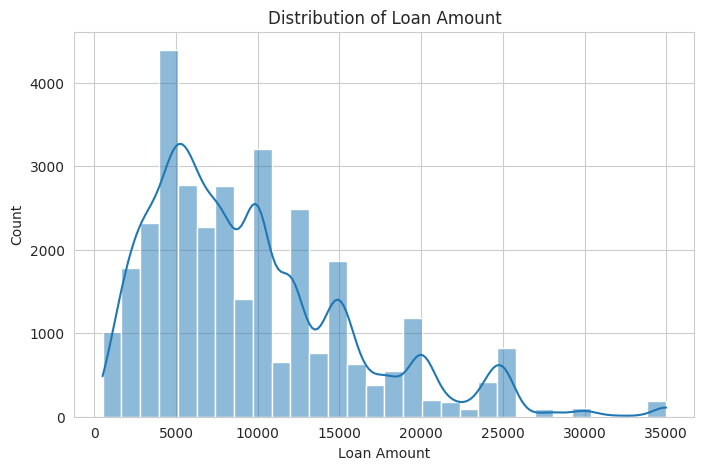

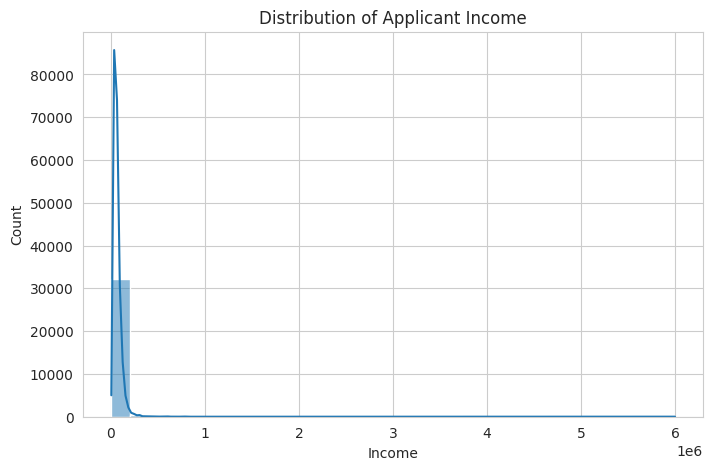

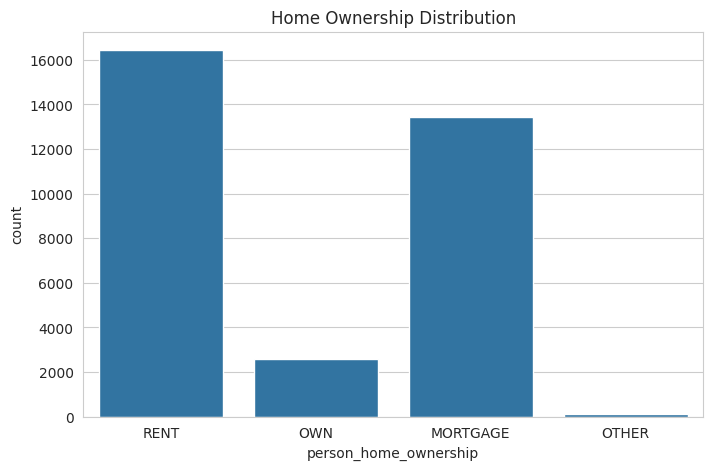

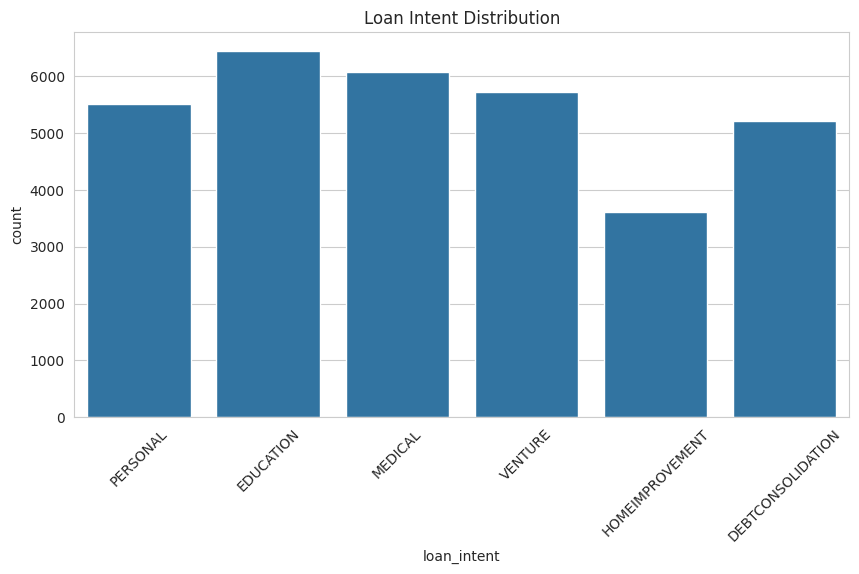

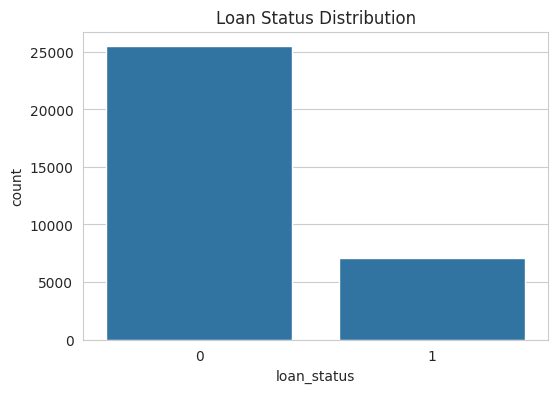

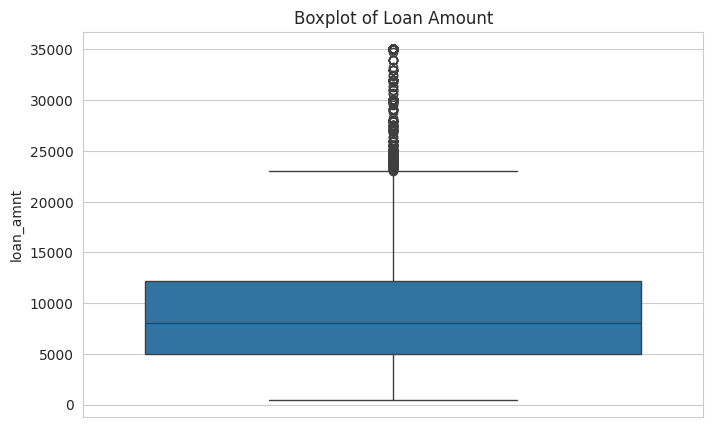


Training Samples: 26064
Testing Samples : 6517

Accuracy Score:
83.21 %

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.95      0.90      5072
           1       0.71      0.41      0.52      1445

    accuracy                           0.83      6517
   macro avg       0.78      0.68      0.71      6517
weighted avg       0.82      0.83      0.81      6517



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


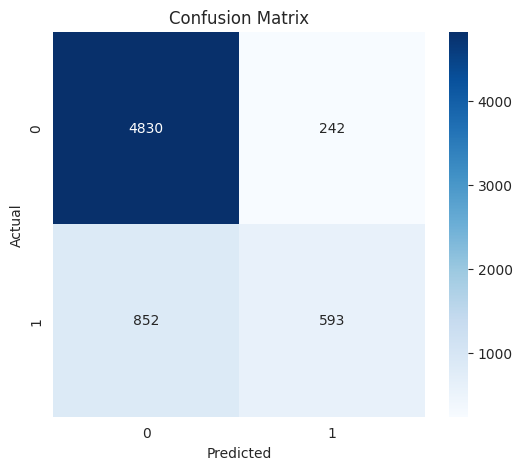


CONCLUSION

1. Missing values were handled successfully.
2. EDA was performed using histograms, countplots,
   and boxplots.
3. Categorical features were encoded using LabelEncoder.
4. Logistic Regression was used to predict credit risk.
5. Model performance was evaluated using:
   - Accuracy Score
   - Confusion Matrix
   - Classification Report
6. The model can help identify applicants who may
   default on a loan.



In [8]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# =====================================================
# 2. Load Dataset
# =====================================================

df = pd.read_csv("/content/credit_risk_dataset.csv")

# =====================================================
# 3. Dataset Understanding
# =====================================================

print("="*50)
print("DATASET SHAPE")
print("="*50)
print(df.shape)

print("\nDATASET COLUMNS")
print(df.columns)

print("\nFIRST 5 ROWS")
print(df.head())

print("\nDATASET INFORMATION")
print(df.info())

print("\nSTATISTICAL SUMMARY")
print(df.describe())

# =====================================================
# 4. Data Cleaning
# =====================================================

print("\nMISSING VALUES")
print(df.isnull().sum())

# Fill missing numerical values using median
df["person_emp_length"] = df["person_emp_length"].fillna(
    df["person_emp_length"].median()
)

df["loan_int_rate"] = df["loan_int_rate"].fillna(
    df["loan_int_rate"].median()
)

# Check again
print("\nMISSING VALUES AFTER CLEANING")
print(df.isnull().sum())

# =====================================================
# 5. Exploratory Data Analysis (EDA)
# =====================================================

# Loan Amount Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["loan_amnt"], bins=30, kde=True)
plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.show()

# Income Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["person_income"], bins=30, kde=True)
plt.title("Distribution of Applicant Income")
plt.xlabel("Income")
plt.show()

# Home Ownership
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="person_home_ownership")
plt.title("Home Ownership Distribution")
plt.show()

# Loan Intent
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="loan_intent")
plt.title("Loan Intent Distribution")
plt.xticks(rotation=45)
plt.show()

# Loan Status
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="loan_status")
plt.title("Loan Status Distribution")
plt.show()

# Boxplot for Loan Amount
plt.figure(figsize=(8,5))
sns.boxplot(y=df["loan_amnt"])
plt.title("Boxplot of Loan Amount")
plt.show()

# =====================================================
# 6. Data Preprocessing
# =====================================================

label_encoder = LabelEncoder()

categorical_columns = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

# =====================================================
# 7. Features and Target
# =====================================================

X = df.drop("loan_status", axis=1)
y = df["loan_status"]

# =====================================================
# 8. Train-Test Split
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Samples:", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

# =====================================================
# 9. Train Logistic Regression Model
# =====================================================

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

# =====================================================
# 10. Predictions
# =====================================================

y_pred = model.predict(X_test)

# =====================================================
# 11. Model Evaluation
# =====================================================

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy Score:")
print(round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =====================================================
# 12. Conclusion
# =====================================================

print("""
==================================================
CONCLUSION
==================================================

1. Missing values were handled successfully.
2. EDA was performed using histograms, countplots,
   and boxplots.
3. Categorical features were encoded using LabelEncoder.
4. Logistic Regression was used to predict credit risk.
5. Model performance was evaluated using:
   - Accuracy Score
   - Confusion Matrix
   - Classification Report
6. The model can help identify applicants who may
   default on a loan.
""")